In [1]:
import torch.utils.data
from torchvision.transforms.v2 import RandomCrop
from src.data.dataset import SeverstalSteelDefectDataset

dataset = SeverstalSteelDefectDataset(
    images_path="../data/train_images",
    label_csv="../data/train.csv",
    transform=RandomCrop((256, 1000))
)

Image shape: torch.Size([1, 256, 1000]), Class label: 1


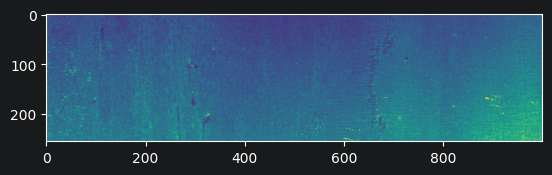

In [3]:
from matplotlib.pyplot import imshow

imshow(dataset[0][0].permute(1, 2, 0))
print(f"Image shape: {dataset[0][0].shape}, Class label: {dataset[0][1]}")

In [2]:
from src.data.split import stratified_train_test_split

train, val = stratified_train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")

# class distribution of each set
train_labels = [label for _, label in train]
val_labels = [label for _, label in val]

print(f"Train class distribution: {dict(sorted({label: train_labels.count(label) for label in set(train_labels)}.items()))}")
print(f"Validation class distribution: {dict(sorted({label: val_labels.count(label) for label in set(val_labels)}.items()))}")

Train size: 5676
Validation size: 1419
Train class distribution: {np.int64(1): 718, np.int64(2): 197, np.int64(3): 4120, np.int64(4): 641}
Validation class distribution: {np.int64(1): 179, np.int64(2): 50, np.int64(3): 1030, np.int64(4): 160}


In [ ]:
train